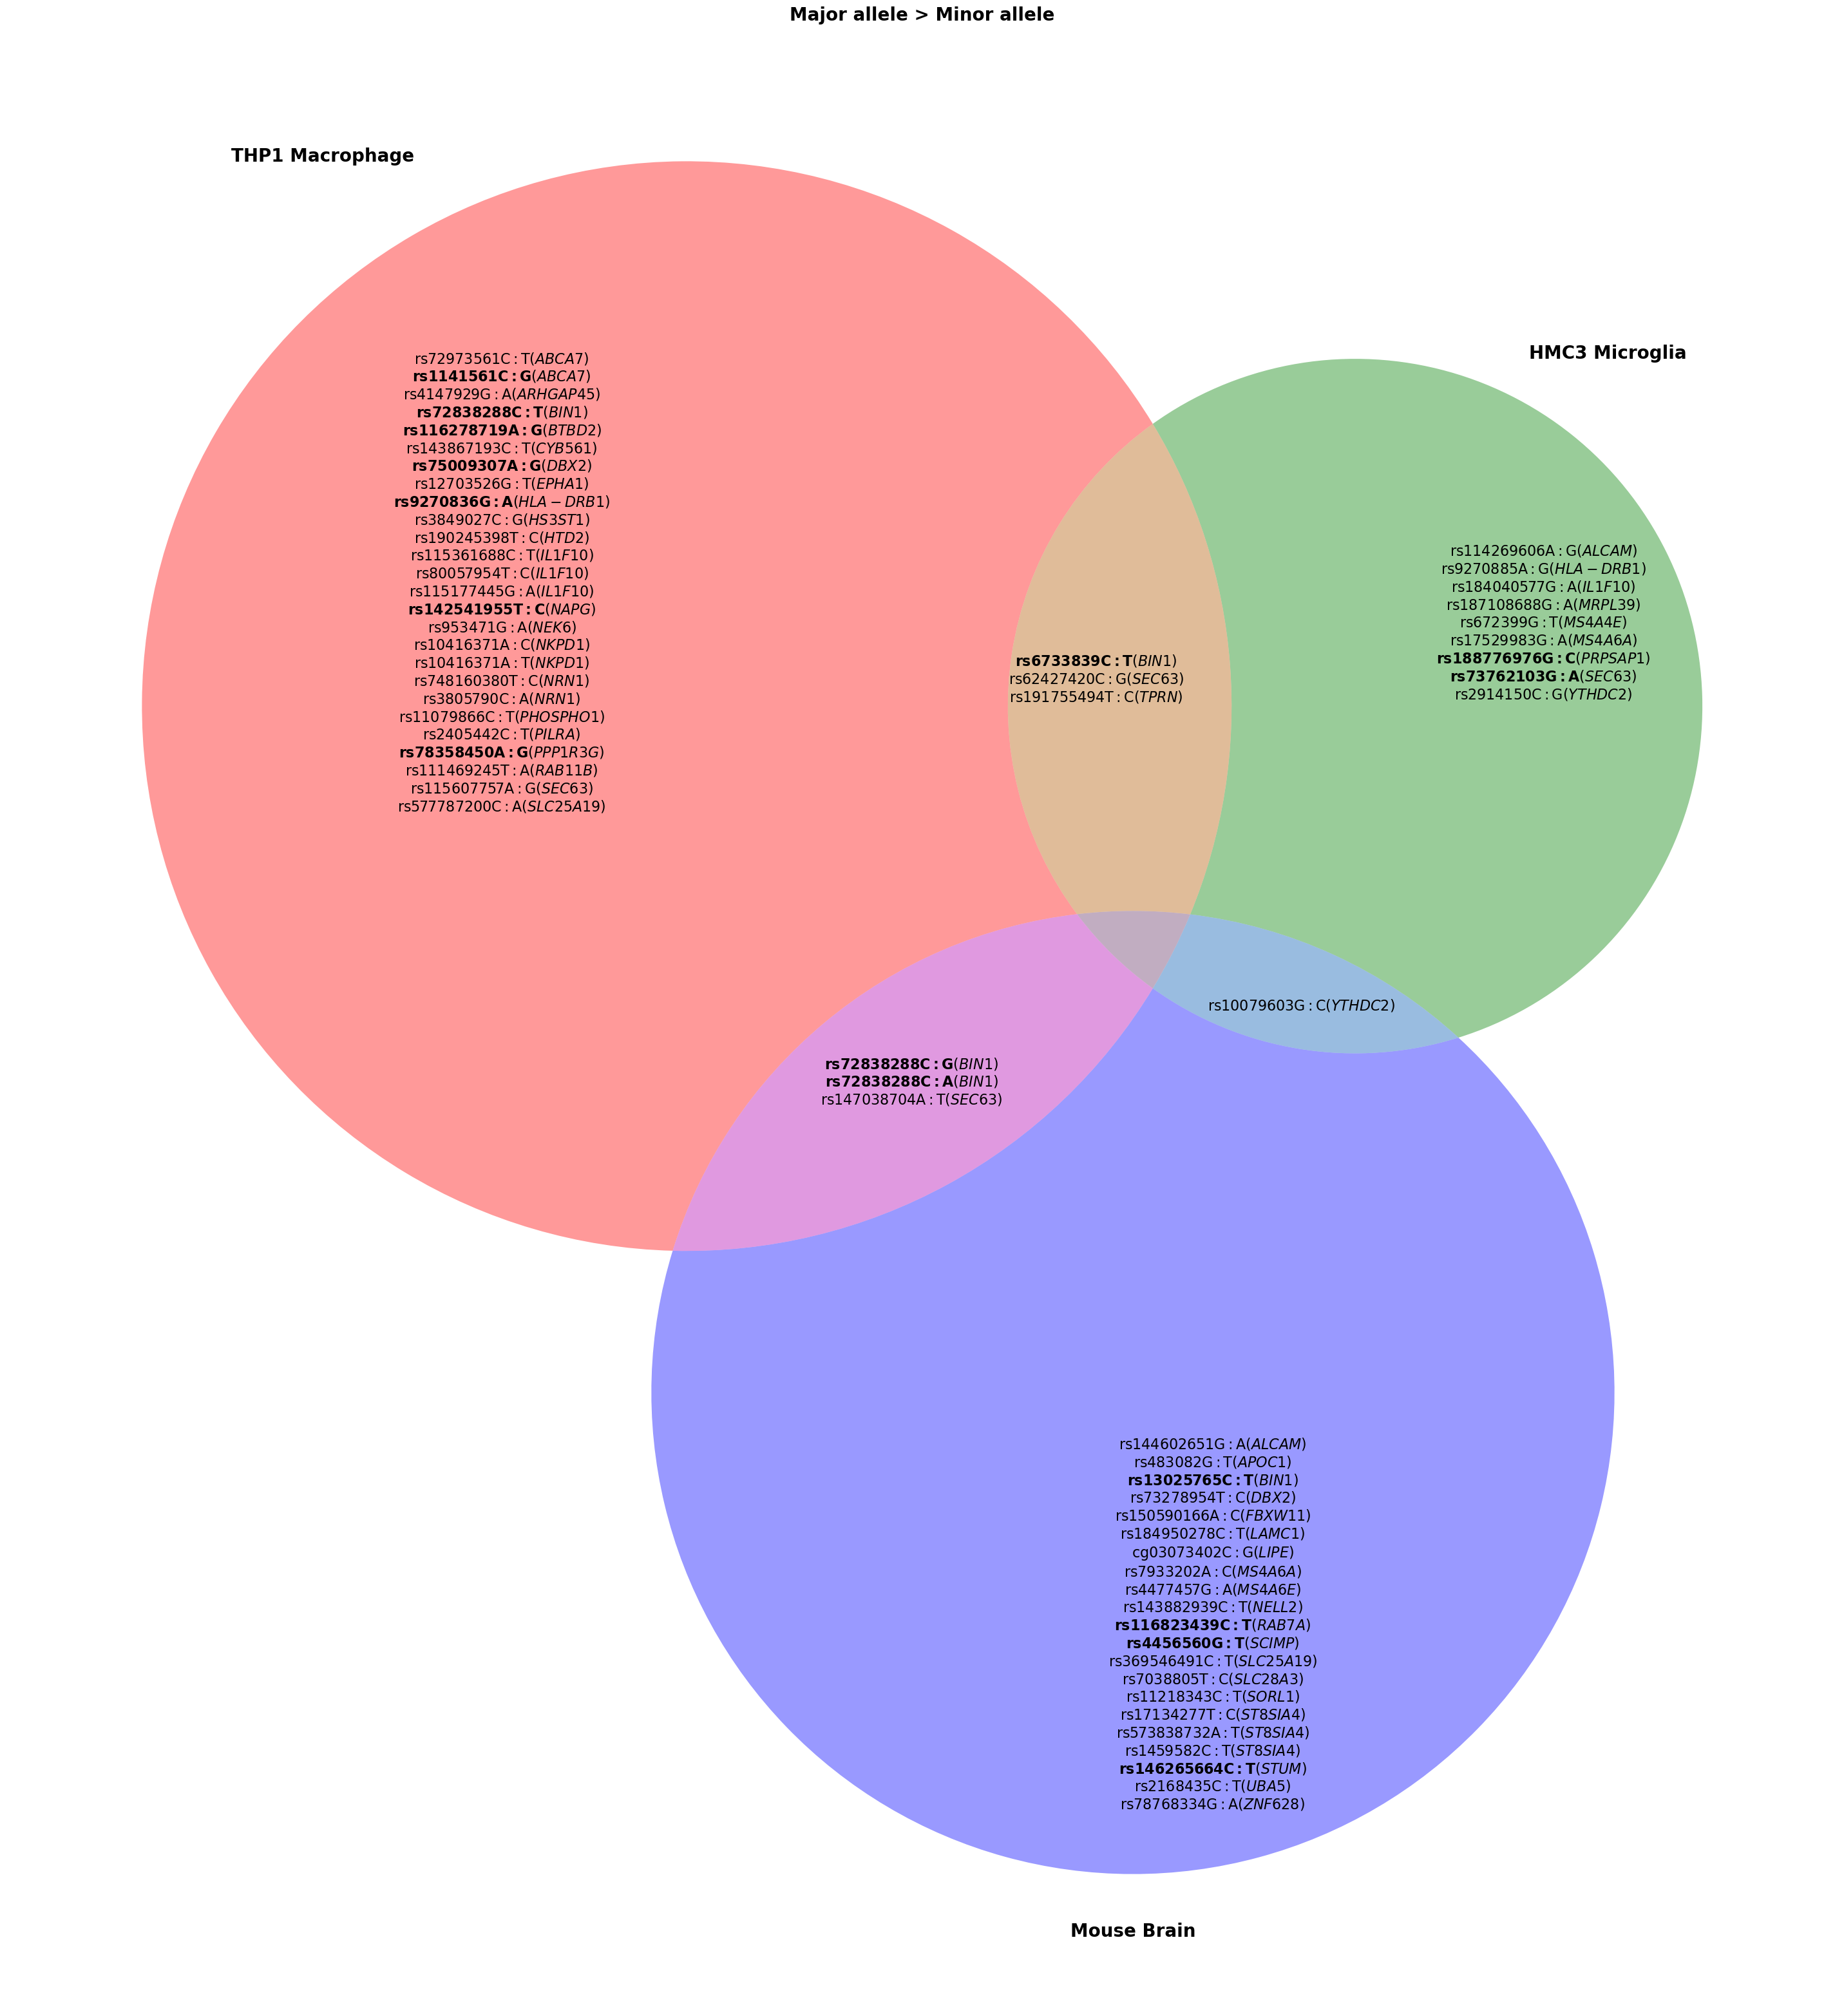

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
df_ml = pd.read_csv("indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_20250608.csv",index_col=0)
#df_ml_sig_brain = df_ml[[       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model',
#       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC',]].dropna(how='all')
df_ml_sig_brain = df_ml[[       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model',
       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model',
       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB',
       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC',]].dropna(how='all')
df_ml_sig_immune = df_ml[[ 'ML_majorminor_logFC_genomic_THP1_IFNB-Calvin',
       'ML_majorminor_logFC_genomic_THP1_IFNG-Calvin',
       'ML_majorminor_logFC_genomic_THP1_LPSIFNG-Calvin',     'ML_majorminor_logFC_genomic_THP1_Naive-Calvin',]].dropna(how='all')

# Read your CSV files into DataFrames
df_Brain = pd.read_csv('causal_alleles/20241029_BrainR1R2merged20240404_Major_greater_Minor_case135_withMAD.csv', index_col=0)
df_HMC3 = pd.read_csv('causal_alleles/20241029_HMC3_Major_greater_Minor_case135_withMAD.csv', index_col=0)
df_THP1 = pd.read_csv('causal_alleles/20241029_THP1Macrophage_Major_greater_Minor_case135_withMAD.csv', index_col=0)
df_case135 = pd.concat([df_Brain,df_HMC3,df_THP1])
# Extract unique RSID values from each DataFrame
rsid_THP1 = set(df_THP1['rsid_gene_tss'].unique())
rsid_HMC3 = set(df_HMC3['rsid_gene_tss'].unique())
rsid_Brain = set(df_Brain['rsid_gene_tss'].unique())

# Prepare the RSID sets for each section
only_THP1 = rsid_THP1 - rsid_HMC3 - rsid_Brain
only_HMC3 = rsid_HMC3 - rsid_THP1 - rsid_Brain
only_Brain = rsid_Brain - rsid_THP1 - rsid_HMC3
THP1_HMC3 = (rsid_THP1 & rsid_HMC3) - rsid_Brain
THP1_Brain = (rsid_THP1 & rsid_Brain) - rsid_HMC3
HMC3_Brain = (rsid_HMC3 & rsid_Brain) - rsid_THP1
All_three = rsid_THP1 & rsid_HMC3 & rsid_Brain

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 1 or 3
rsid_bold_dict = {}

for df in [df_THP1, df_HMC3, df_Brain]:
    for rsid_gene in df['rsid_gene_tss'].unique():
        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
        if any(df_subset['Case'].isin([1, 3])):
            rsid_bold_dict[rsid_gene] = True
        else:
            # Keep existing True value if already set
            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

# Function to extract gene name from RSID string
def extract_gene_name(rsid_str):
    match = re.search(r'\((.*?)\)', rsid_str)
    if match:
        return match.group(1)
    else:
        return rsid_str  # Return the whole string if no gene name is found

def format_rsid_gene(rsid_str):
    # Match the pattern: anything before '(', the gene name inside '()', and anything after ')'
    match = re.match(r'(.*?)(\((.*?)\))(.*)', rsid_str)
    if match:
        before_paren = match.group(1)
        paren_content = match.group(2)  # Includes parentheses
        gene_name = match.group(3)      # Inside parentheses
        after_paren = match.group(4)
        
        # Escape underscores
        before_paren = before_paren.replace('_', r'\_')
        gene_name = gene_name.replace('_', r'\_')
        after_paren = after_paren.replace('_', r'\_')
        
        # Italicize gene name
        gene_name_formatted = r'\mathit{' + gene_name + '}'
        paren_content_formatted = '(' + gene_name_formatted + ')'
        
        if rsid_bold_dict.get(rsid_str, False):
            # Bold parts outside parentheses
            before_paren = r'\mathbf{' + before_paren + '}'
            after_paren = r'\mathbf{' + after_paren + '}'
        else:
            # Use upright font for parts outside parentheses
            before_paren = r'\mathrm{' + before_paren + '}'
            after_paren = r'\mathrm{' + after_paren + '}'
        
        # Build the formatted string
        formatted_rsid = before_paren + paren_content_formatted + after_paren
    else:
        # No parentheses found; apply bold or upright font if needed
        formatted_rsid = rsid_str.replace('_', r'\_')
        if rsid_bold_dict.get(rsid_str, False):
            formatted_rsid = r'\mathbf{' + formatted_rsid + '}'
        else:
            formatted_rsid = r'\mathrm{' + formatted_rsid + '}'
    
    # Wrap in $...$ to enable math text rendering
    formatted_rsid = '$' + formatted_rsid + '$'
    return formatted_rsid
# Create the Venn diagram with increased figure size
plt.figure(figsize=(40,40))  # Increase the figure size for better readability
venn = venn3([rsid_THP1, rsid_HMC3, rsid_Brain], ('THP1 Macrophage', 'HMC3 Microglia', 'Mouse Brain'))

# Adjust font sizes and make only set labels bold
for text in venn.set_labels:
    text.set_fontsize(20)
    text.set_fontweight('bold')  # Make the set labels bold
for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        # Do not set font weight to bold for subset labels

# Annotate the Venn diagram with RSIDs sorted by gene name and formatted accordingly
def annotate_venn(venn, sets):
    subset_ids = ['100', '010', '110', '001', '101', '011', '111']
    for idx, subset_id in enumerate(subset_ids):
        label = venn.get_label_by_id(subset_id)
        if label:
            rsids = sets[idx]
            if rsids:
                # Format each RSID string
                rsids_formatted = [format_rsid_gene(rsid) for rsid in rsids]
                # Join RSIDs with line breaks for display
                label.set_text('\n'.join(rsids_formatted))
            else:
                label.set_text('')

# Create a list of sorted RSID lists corresponding to Venn diagram subsets
sets = [
    sorted(only_THP1, key=extract_gene_name),
    sorted(only_HMC3, key=extract_gene_name),
    sorted(THP1_HMC3, key=extract_gene_name),
    sorted(only_Brain, key=extract_gene_name),
    sorted(THP1_Brain, key=extract_gene_name),
    sorted(HMC3_Brain, key=extract_gene_name),
    sorted(All_three, key=extract_gene_name)
]

# Annotate the Venn diagram
annotate_venn(venn, sets)

# Set the title with bold font weight
plt.title('Major allele > Minor allele', fontsize=20, fontweight='bold')

# Enable LaTeX-style math text rendering
plt.rcParams['text.usetex'] = False  # Keep False to use matplotlib's built-in math rendering
plt.rcParams['mathtext.fontset'] = 'stix'

# Save the figure to a PDF file
#plt.savefig('venn_diagram_major_greater_minor.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()


In [2]:
!pip install matplotlib_venn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib_venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=21e54e1518c4fb195033473983d4b0728aa4890fa18f00e40a5e1bde79104768
  Stored in directory: /Users/zihengc/Library/Caches/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib_venn


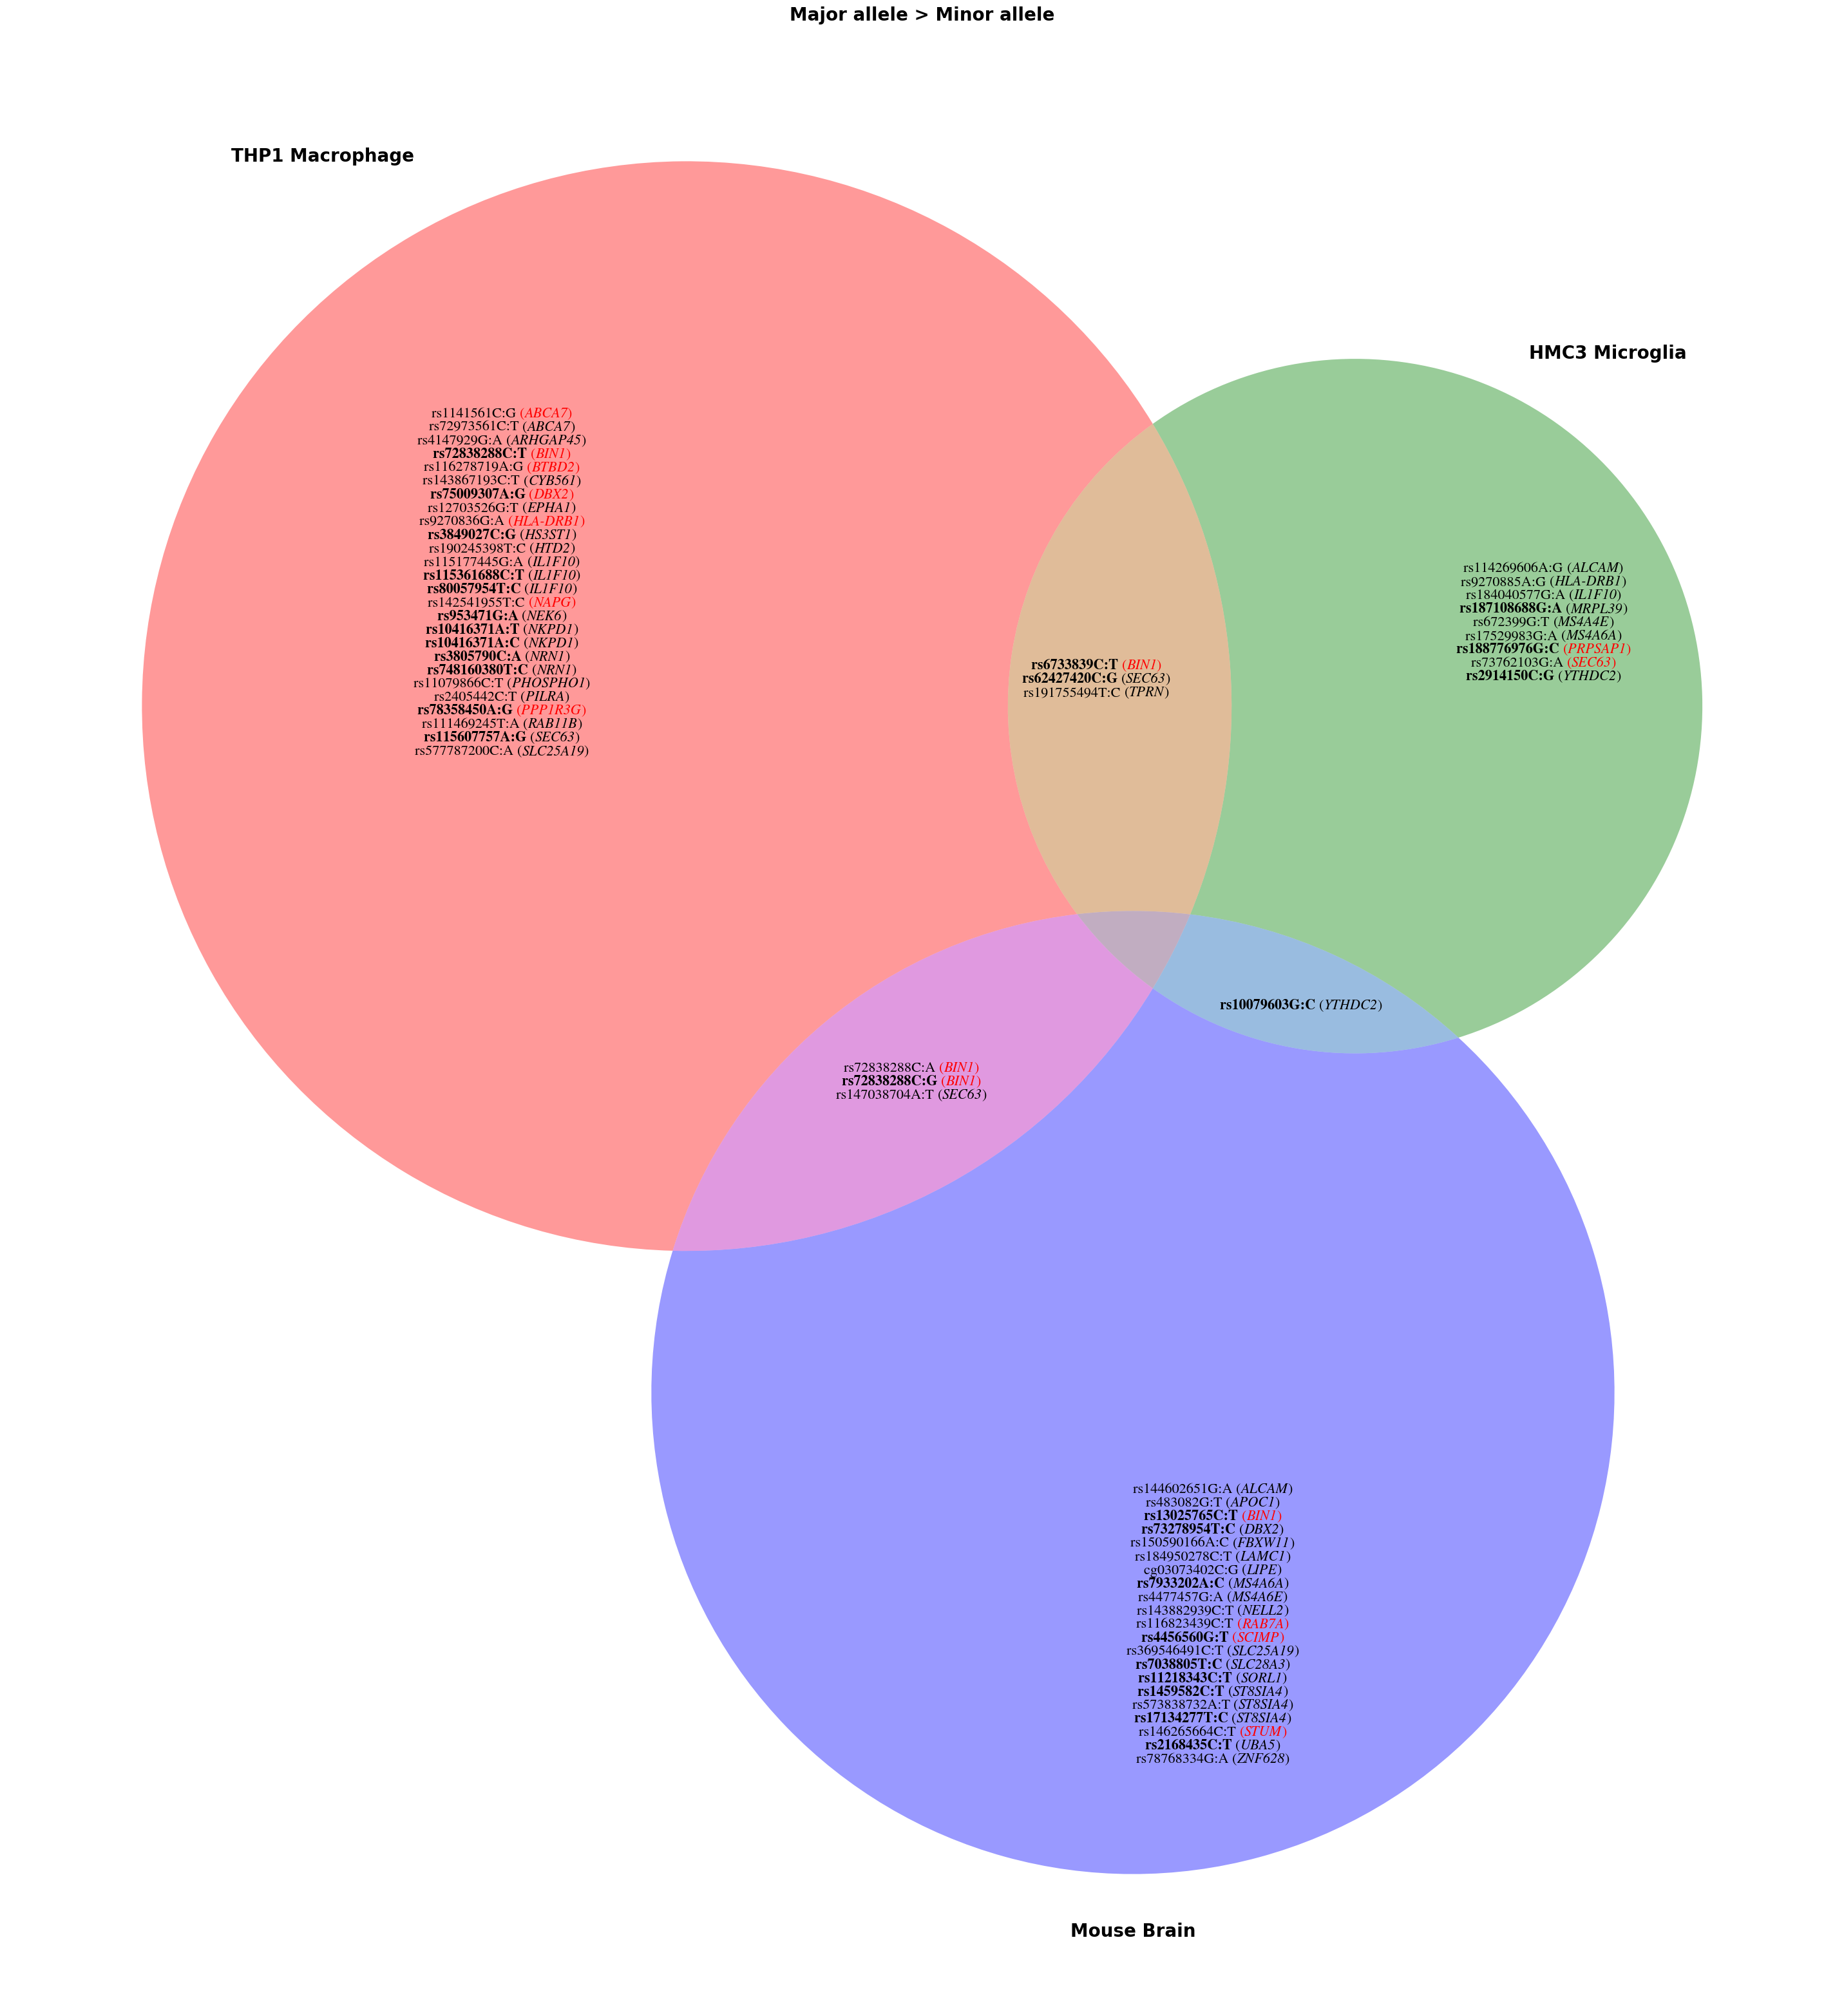

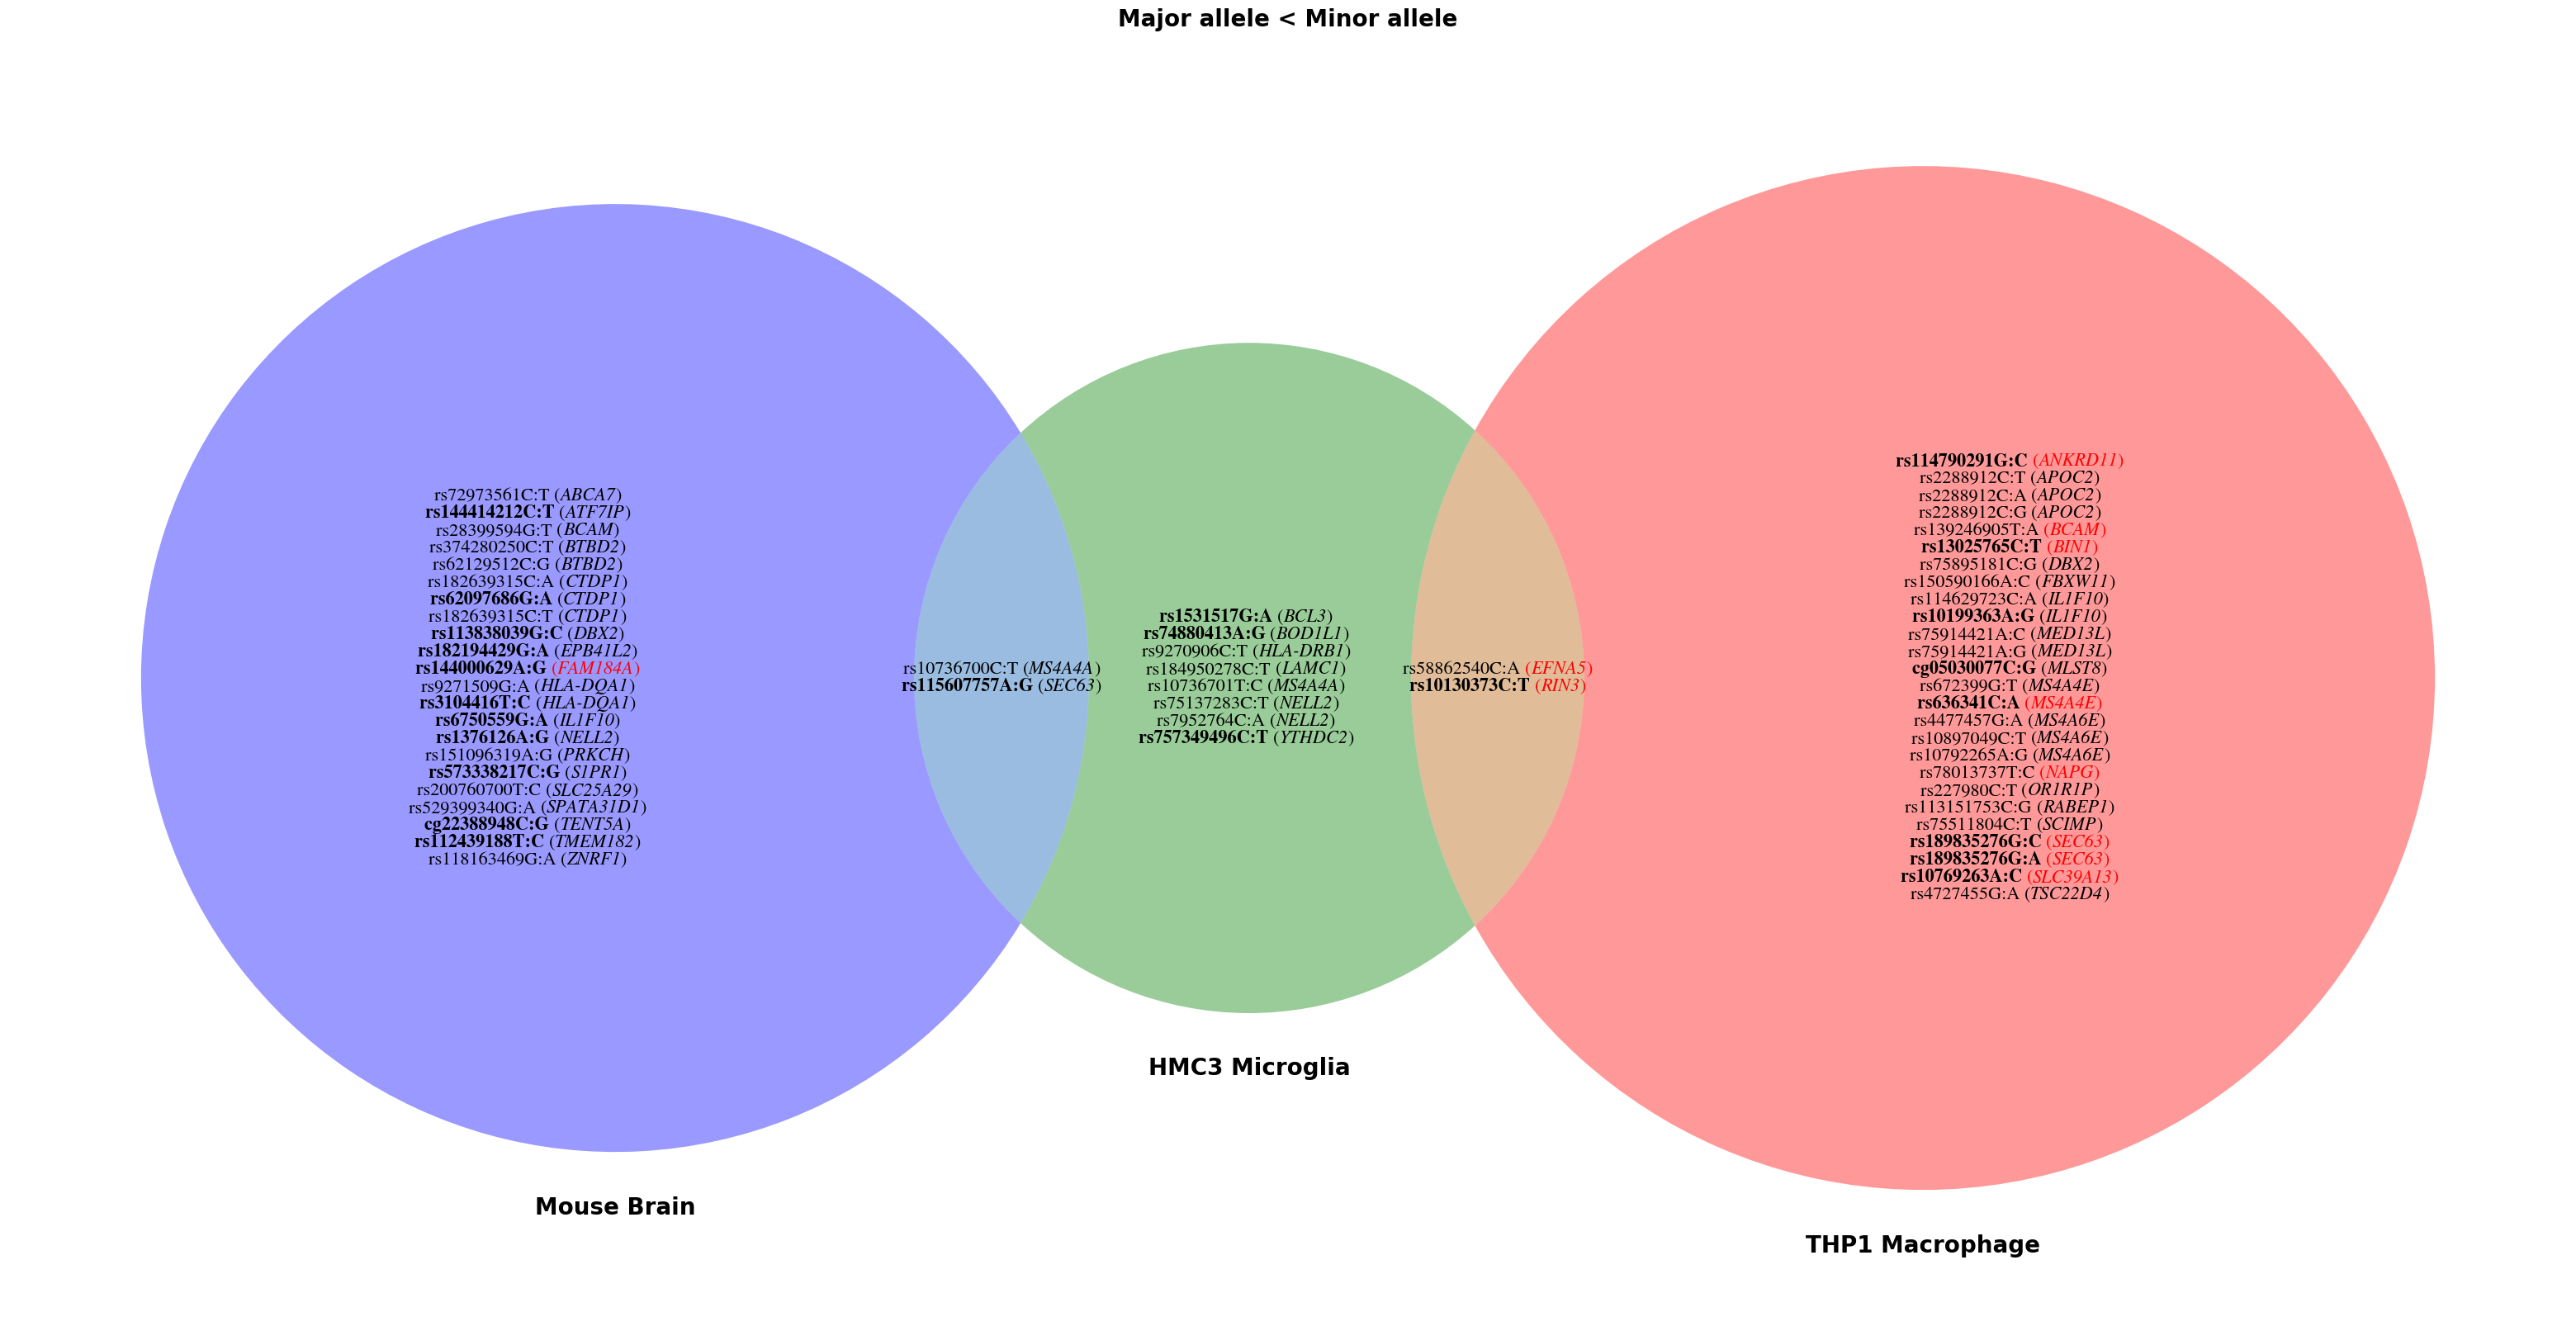

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import TextArea, HPacker, VPacker, AnnotationBbox


# ============================================================
# Global font settings
# Apply these settings BEFORE drawing either figure so that the
# two exported PDFs use the same font configuration.
# ============================================================
plt.rcParams['text.usetex'] = False  # Keep False to use matplotlib's built-in rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'DejaVu Sans'

# Font used for the RSID lines inside the Venn-diagram circles.
# STIXGeneral gives a serif appearance similar to the original figure.
RSID_FONT_FAMILY = 'STIXGeneral'
RSID_FONT_SIZE = 16
SET_LABEL_FONT_SIZE = 20
TITLE_FONT_SIZE = 20


# ============================================================
# Hard-coded red annotations
# Match by rsID only, rather than by the entire rsid_gene_tss string.
# This is more robust because allele and annotation formatting may differ
# slightly across CSV files. Only the listed rsIDs will be colored red.
# ============================================================
RED_RSID_IDS_MAJOR_GREATER_MINOR = {
    # THP-1 Macrophages only
    'rs1141561',
    'rs72838288',
    'rs116278719',
    'rs75009307',
    'rs9270836',
    'rs142541955',
    'rs78358450',

    # HMC3 Microglia only
    'rs188776976',
    'rs73762103',

    # THP-1 Macrophages and HMC3 Microglia overlap
    'rs6733839',

    # Brain Tissue only
    'rs13025765',
    'rs116823439',
    'rs4456560',
    'rs146265664',
}

RED_RSID_IDS_MAJOR_LESS_MINOR = {
    # Brain Tissue only
    'rs144000629',

    # HMC3 Microglia and THP-1 Macrophages overlap
    'rs58862540',
    'rs10130373',

    # THP-1 Macrophages only
    'rs114790291',
    'rs139246905',
    'rs13025765',
    'rs636341',
    'rs78013737',
    'rs189835276',
    'rs10769263',
}


# ============================================================
# Load ML-supported variants
# ============================================================
df_ml = pd.read_csv(
    'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_20250608.csv',
    index_col=0
)

#df_ml_sig_brain = df_ml[[       
#       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model',
#       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC',
#       'ML_majorminor_diff_genomic_Mouse_Cortex_AgeB-model',
#       'ML_majorminor_diff_genomic_Mouse_Cortex_AgeC-model',
#       'ML_majorminor_diff_genomic_Mouse_Striatum_AgeB',
#       'ML_majorminor_diff_genomic_Mouse_Striatum_AgeC',
#       ]].dropna(how='all')

# Human neuronal models used for variants detected in mouse-brain MPRA.
df_ml_sig_brain = df_ml[[       
       'ML_majorminor_logFC_genomic_fullard_DLPFC-model-best',
       'ML_majorminor_logFC_genomic_fullard_hippocampus-model-best',
       'ML_majorminor_logFC_genomic_fullard_putamen-model-best',
       'ML_majorminor_diff_genomic_fullard_DLPFC-model-best',
       'ML_majorminor_diff_genomic_fullard_hippocampus-model-best',
       'ML_majorminor_diff_genomic_fullard_putamen-model-best',
       ]].dropna(how='all')

# THP-1 macrophage models used for variants detected in THP-1 or HMC3 MPRA.
df_ml_sig_immune = df_ml[[ 
       'ML_majorminor_logFC_genomic_THP1_IFNB-Calvin',
       'ML_majorminor_logFC_genomic_THP1_IFNG-Calvin',
       'ML_majorminor_logFC_genomic_THP1_LPSIFNG-Calvin',     
       'ML_majorminor_logFC_genomic_THP1_Naive-Calvin',
       'ML_majorminor_diff_genomic_THP1_IFNB-Calvin',
       'ML_majorminor_diff_genomic_THP1_IFNG-Calvin',
       'ML_majorminor_diff_genomic_THP1_LPSIFNG-Calvin',     
       'ML_majorminor_diff_genomic_THP1_Naive-Calvin',
       ]].dropna(how='all')

# Use sets for fast membership testing.
df_ml_sig_brain_rsid = set(
    df_ml.loc[df_ml_sig_brain.index, 'rsid_gene_tss'].dropna().tolist()
)

df_ml_sig_immune_rsid = set(
    df_ml.loc[df_ml_sig_immune.index, 'rsid_gene_tss'].dropna().tolist()
)


# ============================================================
# Shared helper functions
# ============================================================
def extract_gene_name(rsid_str):
    """
    Extract the gene name inside parentheses for sorting.
    """
    match = re.search(r'\((.*?)\)', rsid_str)
    if match:
        return match.group(1)
    else:
        return rsid_str  # Return the whole string if no gene name is found


def extract_rsid_id(rsid_str):
    """
    Extract only the rsID portion, such as rs6733839, from a full label
    such as rs6733839C:T(BIN1). This avoids exact-string mismatches caused
    by allele or annotation formatting differences.
    """
    match = re.search(r'rs\d+', str(rsid_str))
    if match:
        return match.group(0)
    else:
        return str(rsid_str)


def is_ml_supported(rsid_str, rsid_THP1, rsid_HMC3, rsid_Brain):
    """
    Determine whether an RSID should be bold based on ML support.

    1) Variants detected in mouse-brain MPRA are evaluated using
       human neuronal models.

    2) Variants detected in THP-1 macrophages or HMC3 cells are
       evaluated using THP-1 macrophage models.

    3) For variants detected in multiple MPRA contexts, support
       from either corresponding model group is sufficient.
    """
    brain_supported = (
        rsid_str in rsid_Brain and
        rsid_str in df_ml_sig_brain_rsid
    )

    immune_supported = (
        (rsid_str in rsid_HMC3 or rsid_str in rsid_THP1) and
        rsid_str in df_ml_sig_immune_rsid
    )

    return brain_supported or immune_supported


def make_text_area(
    text,
    fontsize,
    color='black',
    weight='normal',
    style='normal'
):
    """
    Make one text segment for an RSID label.
    """
    font_properties = FontProperties(
        family=RSID_FONT_FAMILY,
        size=fontsize,
        weight=weight,
        style=style
    )

    return TextArea(
        text,
        textprops={
            'fontproperties': font_properties,
            'color': color
        }
    )


def make_rsid_line_box(rsid_str, should_bold=False, should_red=False, fontsize=16):
    """
    Create one RSID line as independently formatted text segments.

    - The RSID and allele text remain black.
    - The gene symbol and its parentheses become red only for the
      explicitly hard-coded labels.
    - The gene symbol remains italicized.
    - ML-supported RSID and allele text are bold.
    """
    rsid_weight = 'bold' if should_bold else 'normal'
    match = re.match(r'(.*?)(\((.*?)\))(.*)', rsid_str)

    if match:
        before_paren = match.group(1)
        gene_name = match.group(3)
        after_paren = match.group(4)

        gene_color = 'red' if should_red else 'black'

        pieces = [
            make_text_area(
                before_paren,
                fontsize=fontsize,
                color='black',
                weight=rsid_weight,
                style='normal'
            ),
            make_text_area(
                '(',
                fontsize=fontsize,
                color=gene_color,
                weight='normal',
                style='normal'
            ),
            make_text_area(
                gene_name,
                fontsize=fontsize,
                color=gene_color,
                weight='normal',
                style='italic'
            ),
            make_text_area(
                ')',
                fontsize=fontsize,
                color=gene_color,
                weight='normal',
                style='normal'
            ),
        ]

        if after_paren:
            pieces.append(
                make_text_area(
                    after_paren,
                    fontsize=fontsize,
                    color='black',
                    weight=rsid_weight,
                    style='normal'
                )
            )

    else:
        # No parentheses: keep the full label black.
        pieces = [
            make_text_area(
                rsid_str,
                fontsize=fontsize,
                color='black',
                weight=rsid_weight,
                style='normal'
            )
        ]

    return HPacker(
        children=pieces,
        align='baseline',
        pad=0,
        sep=0
    )


def prepare_venn_sets(df_THP1, df_HMC3, df_Brain):
    """
    Create the seven RSID subsets required by matplotlib_venn.venn3.
    """
    # Extract unique RSID values from each DataFrame
    rsid_THP1 = set(df_THP1['rsid_gene_tss'].dropna().unique())
    rsid_HMC3 = set(df_HMC3['rsid_gene_tss'].dropna().unique())
    rsid_Brain = set(df_Brain['rsid_gene_tss'].dropna().unique())

    # Prepare the RSID sets for each section
    only_THP1 = rsid_THP1 - rsid_HMC3 - rsid_Brain
    only_HMC3 = rsid_HMC3 - rsid_THP1 - rsid_Brain
    only_Brain = rsid_Brain - rsid_THP1 - rsid_HMC3
    THP1_HMC3 = (rsid_THP1 & rsid_HMC3) - rsid_Brain
    THP1_Brain = (rsid_THP1 & rsid_Brain) - rsid_HMC3
    HMC3_Brain = (rsid_HMC3 & rsid_Brain) - rsid_THP1
    All_three = rsid_THP1 & rsid_HMC3 & rsid_Brain

    # The order corresponds to subset IDs:
    # 100, 010, 110, 001, 101, 011, 111
    sets = [
        sorted(only_THP1, key=extract_gene_name),
        sorted(only_HMC3, key=extract_gene_name),
        sorted(THP1_HMC3, key=extract_gene_name),
        sorted(only_Brain, key=extract_gene_name),
        sorted(THP1_Brain, key=extract_gene_name),
        sorted(HMC3_Brain, key=extract_gene_name),
        sorted(All_three, key=extract_gene_name)
    ]

    return rsid_THP1, rsid_HMC3, rsid_Brain, sets


def report_unmatched_red_rsids(red_rsid_id_set, rsid_THP1, rsid_HMC3, rsid_Brain, title):
    """
    Print any hard-coded red labels that do not exactly match an
    rsid_gene_tss value in the current figure.
    """
    all_rsids = rsid_THP1 | rsid_HMC3 | rsid_Brain
    all_rsid_ids = {extract_rsid_id(rsid) for rsid in all_rsids}
    unmatched = sorted(red_rsid_id_set - all_rsid_ids)

    if unmatched:
        print('\nWARNING: The following hard-coded red labels were not found in:')
        print(title)
        print('Check whether the strings exactly match df[\'rsid_gene_tss\'].')
        for rsid in unmatched:
            print('  -', rsid)


def annotate_venn(
    venn,
    sets,
    rsid_THP1,
    rsid_HMC3,
    rsid_Brain,
    red_rsid_id_set,
    fontsize=16,
    line_spacing=0
):
    """
    Replace the region-count labels with RSID labels.

    Each line is built from separate text segments, allowing only
    selected parenthetical gene symbols to become red.
    """
    ax = plt.gca()
    subset_ids = ['100', '010', '110', '001', '101', '011', '111']

    for idx, subset_id in enumerate(subset_ids):
        label = venn.get_label_by_id(subset_id)

        if label is None:
            continue

        # Use the original subset-label position as the center point.
        x, y = label.get_position()

        # Remove matplotlib_venn's original count label.
        label.set_text('')

        rsids = sets[idx]
        if not rsids:
            continue

        line_boxes = []

        for rsid in rsids:
            should_bold = is_ml_supported(
                rsid,
                rsid_THP1=rsid_THP1,
                rsid_HMC3=rsid_HMC3,
                rsid_Brain=rsid_Brain
            )

            should_red = extract_rsid_id(rsid) in red_rsid_id_set

            line_boxes.append(
                make_rsid_line_box(
                    rsid_str=rsid,
                    should_bold=should_bold,
                    should_red=should_red,
                    fontsize=fontsize
                )
            )

        multiline_box = VPacker(
            children=line_boxes,
            align='center',
            pad=0,
            sep=line_spacing
        )

        annotation_box = AnnotationBbox(
            multiline_box,
            (x, y),
            xycoords='data',
            box_alignment=(0.5, 0.5),
            frameon=False,
            pad=0
        )

        ax.add_artist(annotation_box)


def plot_venn(
    df_THP1,
    df_HMC3,
    df_Brain,
    title,
    output_pdf,
    red_rsid_id_set
):
    """
    Generate one Venn diagram using shared formatting settings.
    """
    rsid_THP1, rsid_HMC3, rsid_Brain, sets = prepare_venn_sets(
        df_THP1=df_THP1,
        df_HMC3=df_HMC3,
        df_Brain=df_Brain
    )

    report_unmatched_red_rsids(
        red_rsid_id_set=red_rsid_id_set,
        rsid_THP1=rsid_THP1,
        rsid_HMC3=rsid_HMC3,
        rsid_Brain=rsid_Brain,
        title=title
    )

    # Create the Venn diagram with increased figure size
    plt.figure(figsize=(40, 40))

    venn = venn3(
        [rsid_THP1, rsid_HMC3, rsid_Brain],
        ('THP1 Macrophage', 'HMC3 Microglia', 'Mouse Brain')
    )

    # Adjust font sizes and make only set labels bold
    for text in venn.set_labels:
        if text:
            text.set_fontsize(SET_LABEL_FONT_SIZE)
            text.set_fontweight('bold')

    for text in venn.subset_labels:
        if text:
            text.set_fontsize(RSID_FONT_SIZE)
            # Do not set font weight to bold for subset labels.
            # Bolding is controlled separately for each RSID line.

    # Annotate the Venn diagram with RSIDs sorted by gene name
    annotate_venn(
        venn=venn,
        sets=sets,
        rsid_THP1=rsid_THP1,
        rsid_HMC3=rsid_HMC3,
        rsid_Brain=rsid_Brain,
        red_rsid_id_set=red_rsid_id_set,
        fontsize=RSID_FONT_SIZE,
        line_spacing=0
    )

    # Set the title with bold font weight
    plt.title(
        title,
        fontsize=TITLE_FONT_SIZE,
        fontweight='bold'
    )

    # Save the figure to a PDF file
    plt.savefig(
        output_pdf,
        format='pdf',
        bbox_inches='tight',
        dpi=300
    )

    plt.show()
    plt.close()


# ============================================================
# Figure 1: Major allele > Minor allele
# ============================================================
# Read your CSV files into DataFrames
df_Brain = pd.read_csv(
    'causal_alleles/20241029_BrainR1R2merged20240404_Major_greater_Minor_case135_withMAD.csv',
    index_col=0
)

df_HMC3 = pd.read_csv(
    'causal_alleles/20241029_HMC3_Major_greater_Minor_case135_withMAD.csv',
    index_col=0
)

df_THP1 = pd.read_csv(
    'causal_alleles/20241029_THP1Macrophage_Major_greater_Minor_case135_withMAD.csv',
    index_col=0
)

df_case135 = pd.concat([df_Brain, df_HMC3, df_THP1])

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 1 or 3
# Retained as comment-out code for reference. The current figure uses
# ML-based bold annotation so that it matches the figure legend.
#rsid_bold_dict = {}
#
#for df in [df_THP1, df_HMC3, df_Brain]:
#    for rsid_gene in df['rsid_gene_tss'].unique():
#        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
#        if any(df_subset['Case'].isin([1, 3])):
#            rsid_bold_dict[rsid_gene] = True
#        else:
#            # Keep existing True value if already set
#            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

plot_venn(
    df_THP1=df_THP1,
    df_HMC3=df_HMC3,
    df_Brain=df_Brain,
    title='Major allele > Minor allele',
    output_pdf='venn_diagram_major_greater_minor_ml_neuron.pdf',
    red_rsid_id_set=RED_RSID_IDS_MAJOR_GREATER_MINOR
)


# ============================================================
# Figure 2: Major allele < Minor allele
# ============================================================
# Read your CSV files into DataFrames
df_Brain = pd.read_csv(
    'causal_alleles/20241029_BrainR1R2merged20240404_Major_less_Minor_case246_withMAD.csv',
    index_col=0
)

df_HMC3 = pd.read_csv(
    'causal_alleles/20241029_HMC3_Major_less_Minor_case246_withMAD.csv',
    index_col=0
)

df_THP1 = pd.read_csv(
    'causal_alleles/20241029_THP1Macrophage_Major_less_Minor_case246_withMAD.csv',
    index_col=0
)

df_case246 = pd.concat([df_Brain, df_HMC3, df_THP1])

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 2 or 4
# Retained as comment-out code for reference. The current figure uses
# ML-based bold annotation so that it matches the figure legend.
#rsid_bold_dict = {}
#
#for df in [df_THP1, df_HMC3, df_Brain]:
#    for rsid_gene in df['rsid_gene_tss'].unique():
#        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
#        if any(df_subset['Case'].isin([2, 4])):
#            rsid_bold_dict[rsid_gene] = True
#        else:
#            # Keep existing True value if already set
#            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

plot_venn(
    df_THP1=df_THP1,
    df_HMC3=df_HMC3,
    df_Brain=df_Brain,
    title='Major allele < Minor allele',
    output_pdf='venn_diagram_major_less_minor_ml_neuron.pdf',
    red_rsid_id_set=RED_RSID_IDS_MAJOR_LESS_MINOR
)


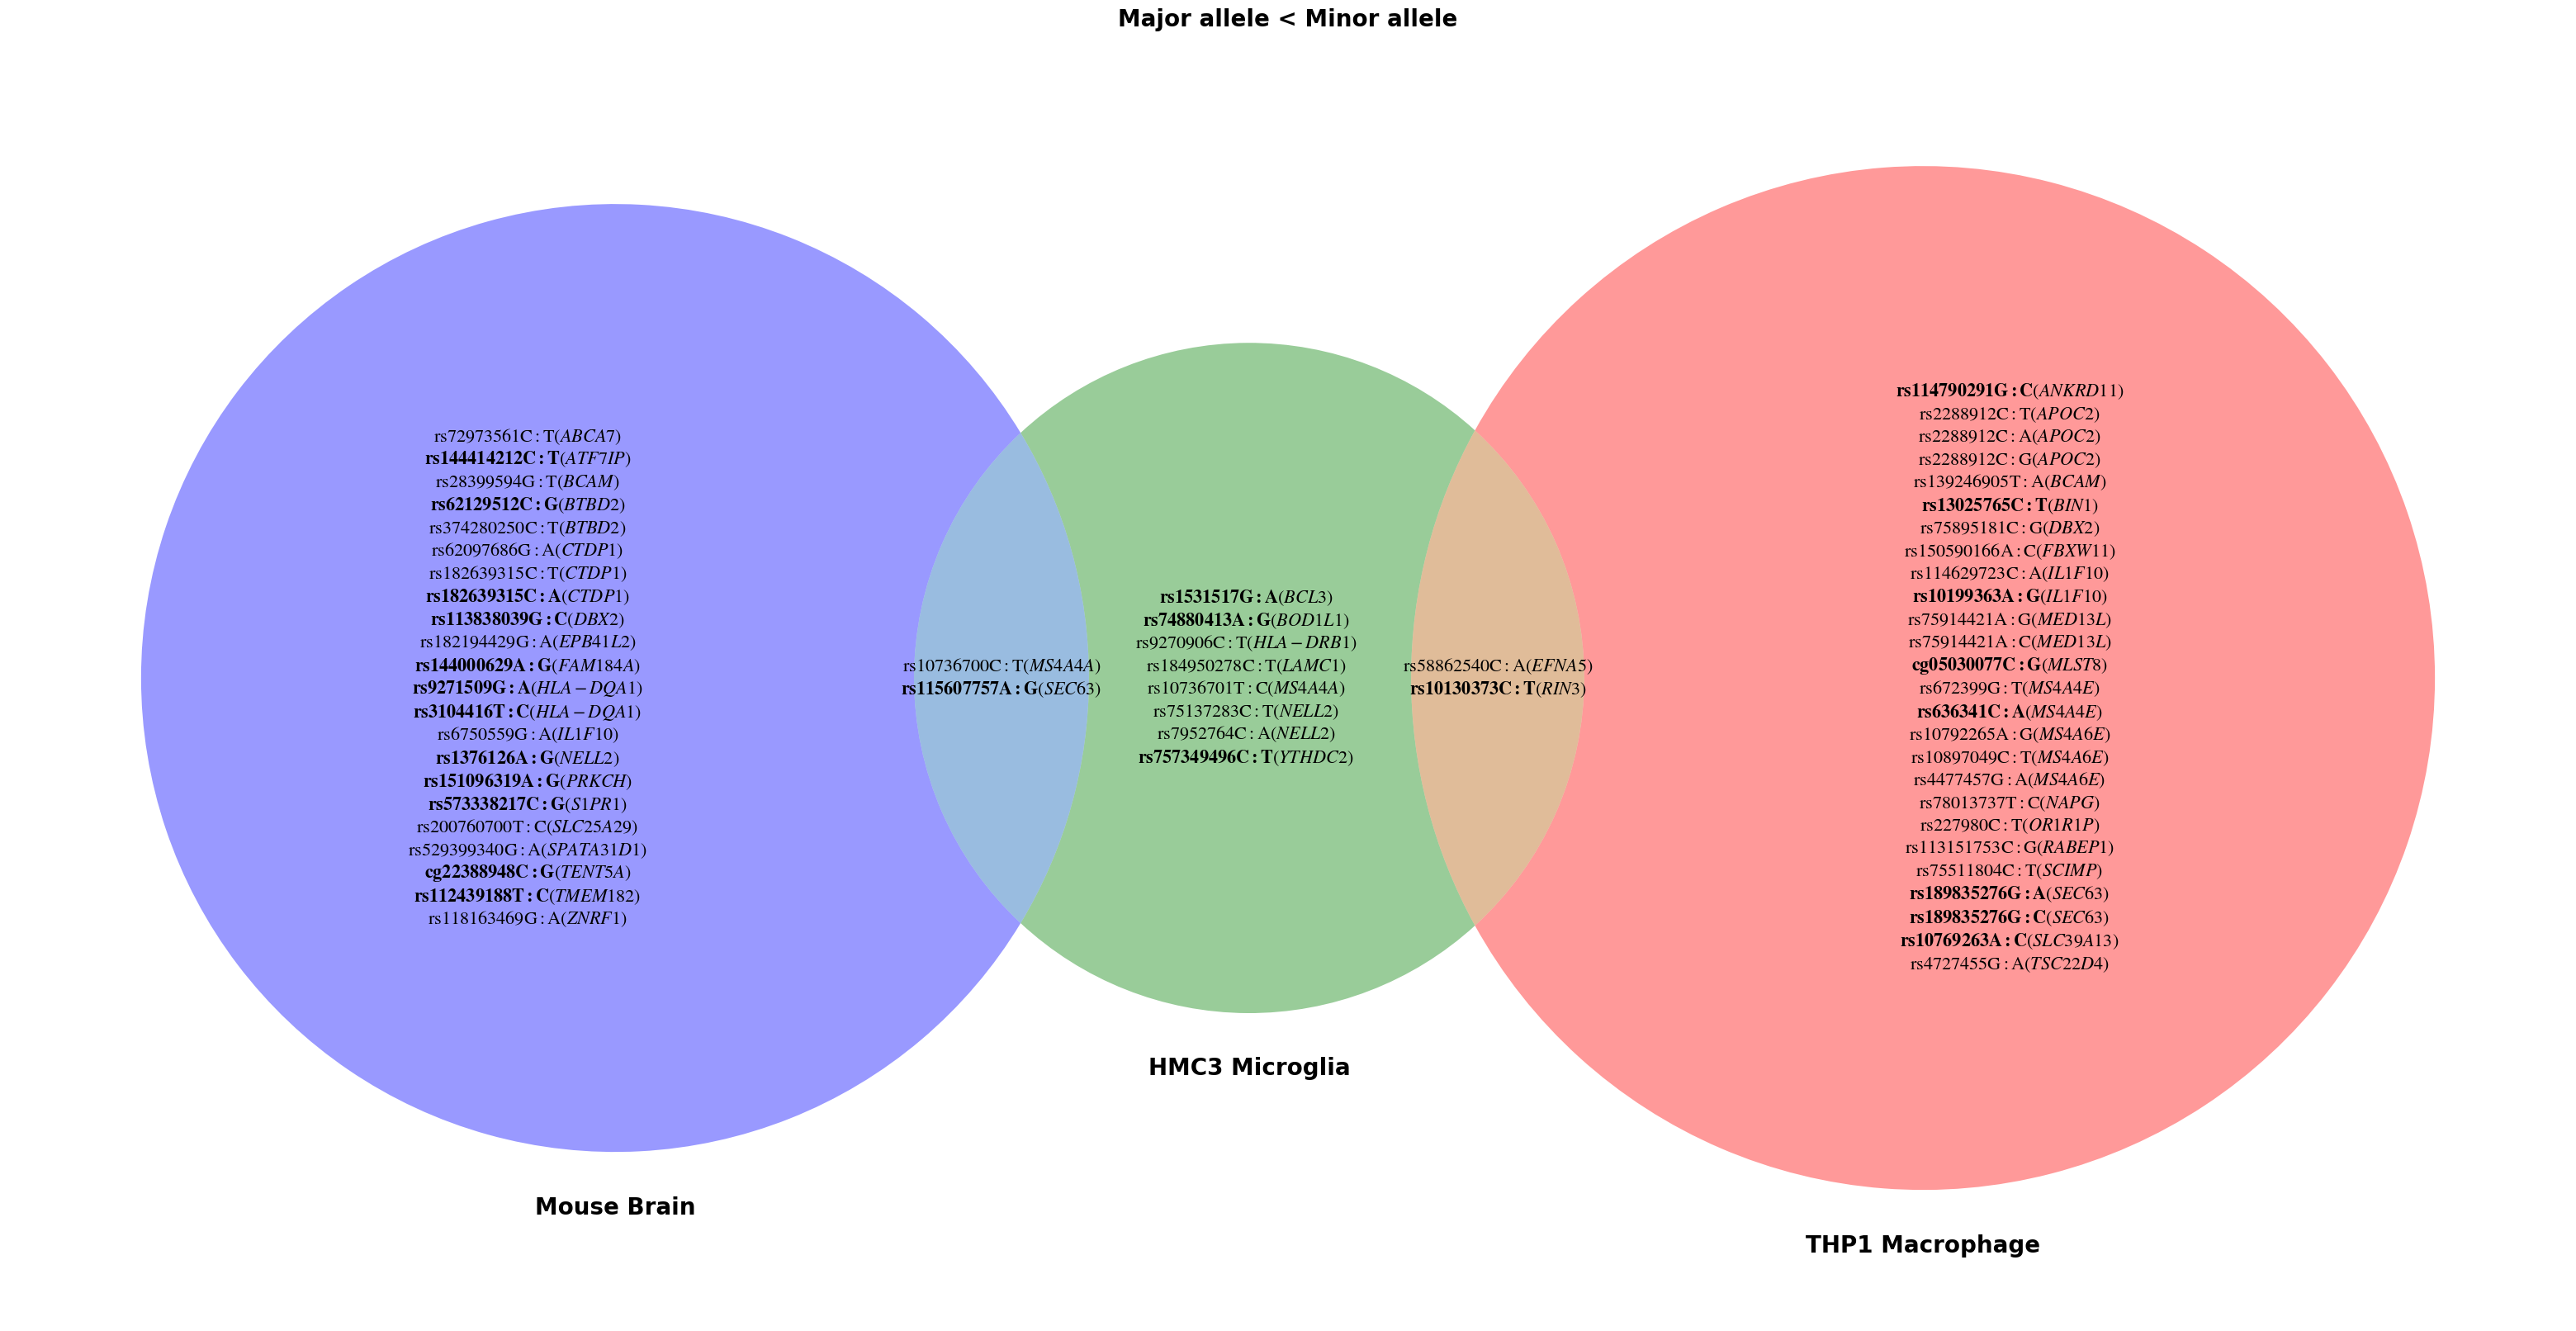

In [34]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Read your CSV files into DataFrames
df_Brain = pd.read_csv('causal_alleles/20241029_BrainR1R2merged20240404_Major_less_Minor_case246_withMAD.csv', index_col=0)
df_HMC3 = pd.read_csv('causal_alleles/20241029_HMC3_Major_less_Minor_case246_withMAD.csv', index_col=0)
df_THP1 = pd.read_csv('causal_alleles/20241029_THP1Macrophage_Major_less_Minor_case246_withMAD.csv', index_col=0)
df_case246 = pd.concat([df_Brain,df_HMC3,df_THP1])
# Extract unique RSID values from each DataFrame
rsid_THP1 = set(df_THP1['rsid_gene_tss'].unique())
rsid_HMC3 = set(df_HMC3['rsid_gene_tss'].unique())
rsid_Brain = set(df_Brain['rsid_gene_tss'].unique())

# Prepare the RSID sets for each section
only_THP1 = rsid_THP1 - rsid_HMC3 - rsid_Brain
only_HMC3 = rsid_HMC3 - rsid_THP1 - rsid_Brain
only_Brain = rsid_Brain - rsid_THP1 - rsid_HMC3
THP1_HMC3 = (rsid_THP1 & rsid_HMC3) - rsid_Brain
THP1_Brain = (rsid_THP1 & rsid_Brain) - rsid_HMC3
HMC3_Brain = (rsid_HMC3 & rsid_Brain) - rsid_THP1
All_three = rsid_THP1 & rsid_HMC3 & rsid_Brain

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 1 or 3
rsid_bold_dict = {}

for df in [df_THP1, df_HMC3, df_Brain]:
    for rsid_gene in df['rsid_gene_tss'].unique():
        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
        if any(df_subset['Case'].isin([2, 4])):
            rsid_bold_dict[rsid_gene] = True
        else:
            # Keep existing True value if already set
            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

# Function to extract gene name from RSID string
def extract_gene_name(rsid_str):
    match = re.search(r'\((.*?)\)', rsid_str)
    if match:
        return match.group(1)
    else:
        return rsid_str  # Return the whole string if no gene name is found


def format_rsid_gene(rsid_str):
    """
    1) If rsid_str is in rsid_Brain & df_ml_sig_brain_rsid OR 
       in (rsid_HMC3 or rsid_THP1) & df_ml_sig_immune_rsid, 
       then we set should_bold = True.
    2) If the RSID string has parentheses, italicize the gene inside parentheses
       and either bold or \mathrm the rest.
    3) If no parentheses, just bold or leave unformatted (escaped).
    """
    # Determine whether this RSID should be bold
    if rsid_str in rsid_Brain and rsid_str in df_ml_sig_brain_rsid.tolist():
        should_bold = True
    elif (rsid_str in rsid_HMC3 or rsid_str in rsid_THP1) and rsid_str in df_ml_sig_immune_rsid.tolist():
        should_bold = True
    else:
        should_bold = False

    # Regex to capture: text before '(', the parentheses with gene, text after ')'
    match = re.match(r'(.*?)(\((.*?)\))(.*)', rsid_str)
    if match:
        before_paren = match.group(1)   # text before '('
        paren_content = match.group(2) # entire parenthetical portion (includes '(' and ')')
        gene_name = match.group(3)     # text inside parentheses
        after_paren = match.group(4)   # text after ')'

        # Escape underscores
        before_paren = before_paren.replace('_', r'\_')
        gene_name = gene_name.replace('_', r'\_')
        after_paren = after_paren.replace('_', r'\_')

        # Italicize the gene name inside parentheses
        gene_name_formatted = r'\mathit{' + gene_name + '}'
        paren_content_formatted = '(' + gene_name_formatted + ')'

        # Bold or upright for the portions outside parentheses
        if should_bold:
            before_paren = r'\mathbf{' + before_paren + '}'
            after_paren = r'\mathbf{' + after_paren + '}'
        else:
            # Use upright (mathrm)
            before_paren = r'\mathrm{' + before_paren + '}'
            after_paren = r'\mathrm{' + after_paren + '}'

        # Combine the pieces
        formatted_rsid = before_paren + paren_content_formatted + after_paren

    else:
        # No parentheses, just escape underscores
        escaped = rsid_str.replace('_', r'\_')
        if should_bold:
            formatted_rsid = r'\mathbf{' + escaped + '}'
        else:
            # If not bold, use upright or leave alone.
            formatted_rsid = r'\mathrm{' + escaped + '}'

    # Wrap in $...$ to render as math text
    formatted_rsid = '$' + formatted_rsid + '$'
    return formatted_rsid



# Create the Venn diagram with increased figure size
plt.figure(figsize=(40, 40))  # Increase the figure size for better readability
venn = venn3([rsid_THP1, rsid_HMC3, rsid_Brain], ('THP1 Macrophage', 'HMC3 Microglia', 'Mouse Brain'))

# Adjust font sizes and make only set labels bold
for text in venn.set_labels:
    text.set_fontsize(20)
    text.set_fontweight('bold')  # Make the set labels bold
for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        # Do not set font weight to bold for subset labels

# Annotate the Venn diagram with RSIDs sorted by gene name and formatted accordingly
def annotate_venn(venn, sets):
    subset_ids = ['100', '010', '110', '001', '101', '011', '111']
    for idx, subset_id in enumerate(subset_ids):
        label = venn.get_label_by_id(subset_id)
        if label:
            rsids = sets[idx]
            if rsids:
                # Format each RSID string
                rsids_formatted = [format_rsid_gene(rsid) for rsid in rsids]
                # Join RSIDs with line breaks for display
                label.set_text('\n'.join(rsids_formatted))
            else:
                label.set_text('')

# Create a list of sorted RSID lists corresponding to Venn diagram subsets
sets = [
    sorted(only_THP1, key=extract_gene_name),
    sorted(only_HMC3, key=extract_gene_name),
    sorted(THP1_HMC3, key=extract_gene_name),
    sorted(only_Brain, key=extract_gene_name),
    sorted(THP1_Brain, key=extract_gene_name),
    sorted(HMC3_Brain, key=extract_gene_name),
    sorted(All_three, key=extract_gene_name)
]

# Annotate the Venn diagram
annotate_venn(venn, sets)

# Set the title with bold font weight
plt.title('Major allele < Minor allele', fontsize=20, fontweight='bold')

# Enable LaTeX-style math text rendering
plt.rcParams['text.usetex'] = False  # Keep False to use matplotlib's built-in math rendering
plt.rcParams['mathtext.fontset'] = 'stix'

# Save the figure to a PDF file
plt.savefig('venn_diagram_major_less_minor_ml.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()
